Of course, I can provide a review of your machine learning project. This is a great first project, and it's a solid effort that covers many key steps in the machine learning workflow.

### \#\# 1. Project Rating

Overall, I would rate this project a **7 out of 10**.

You've successfully gone through the main stages of a machine learning project:

  * **Data Loading and Initial Exploration**: You loaded the data and used `.info()` and `.describe()` to get a feel for it.
  * **Data Cleaning**: You correctly identified and dropped irrelevant or redundant columns like `"track_id"`, `"Unnamed: 5"`, and `"playlist_name.1"`.
  * **Feature Engineering**: You created a clear target variable (`"Populariy_bool"`) from the numerical `"track_popularity"` column, turning a regression problem into a more straightforward classification problem.
  * **Data Preprocessing**: You handled an imbalanced dataset by using `RandomOverSampler` to create a balanced training set.
  * **Modeling and Evaluation**: You built and trained a `RandomForestClassifier` model, tuned its hyperparameters with `GridSearchCV`, and evaluated its performance with a confusion matrix and accuracy scores.

This is a complete and well-executed workflow for a first project.

-----

### \#\# 2. Shortcomings and Improvements

Your approach is good, but there are a few areas where you could improve your process and, likely, your model's performance.

  * **Handling Categorical and Date Features**: Your final feature set (`X`) only included numerical columns. You dropped several potentially useful columns like `"playlist_genre"`, `"track_artist"`, and `"track_album_release_date"`. These could contain valuable information.
      * **Improvement**: Learn to use **one-hot encoding** for categorical features like `"playlist_genre"` and `"playlist_subgenre"`. For `"track_album_release_date"`, you could extract the year or month as a numerical feature.
  * **Feature Scaling**: You did not scale your numerical features. Features like `"duration_ms"` have a much larger range of values than features like `"danceability"`. This can negatively impact the performance of some models.
      * **Improvement**: Before training, use a scaler like **`StandardScaler`** or **`MinMaxScaler`** from scikit-learn to bring all numerical features to a similar scale. This is a standard and crucial preprocessing step.
  * **Data Leakage Check**: You successfully avoided the most common form of data leakage by dropping the original `"track_popularity"` column before training. However, you dropped `"track_name"` *after* setting it as the index. While this worked, it's cleaner to handle all feature selection before defining your `X` and `y` variables.

-----

### \#\# 3. Areas to Focus on for Improvement

Based on your project, here are the key areas to focus on to get better at building ML models:

1.  **Feature Engineering and Preprocessing**: This is the most critical area for growth. Your model is only as good as the data you feed it. Focus on learning techniques to handle different data types:

      * **Categorical Data**: Master one-hot encoding and label encoding.
      * **Numerical Data**: Always remember to scale your data.
      * **Text and Date Data**: Learn how to extract useful features from text (like artist names) or dates.

2.  **Model Evaluation Metrics**: You relied on accuracy and a confusion matrix, which is a great start. Now, learn about other important metrics, especially for classification:

      * **Precision**: Of all the songs you predicted were popular, how many actually were? (Measures false positives).
      * **Recall**: Of all the songs that were actually popular, how many did your model find? (Measures false negatives).
      * **F1-Score**: The harmonic mean of precision and recall, giving a single score that balances both.
      * **ROC Curve and AUC**: These are excellent for visualizing the trade-off between true positive and false positive rates.

3.  **Model Interpretability**: Move beyond just looking at feature importances. For models like Logistic Regression, you can examine the coefficients to see *how* each feature impacts the prediction (positively or negatively). For Decision Trees, you can visualize the exact rules the model learned.

-----

### \#\# 4. How to Predict a New Song's Popularity

Predicting a new song is straightforward once your model is trained. You would need to create a pipeline that includes all your preprocessing steps (like imputation and scaling).

Here’s a conceptual example of how you would do it:

```python
# Assume 'model' is your final, trained pipeline
# and 'scaler' is the StandardScaler you fit on your training data

# 1. Get the new song's data (must have the same features as your training data)
new_song_data = {
    "danceability": 0.75,
    "energy": 0.8,
    "key": 5.0,
    "loudness": -5.5,
    "speechiness": 0.05,
    "acousticness": 0.1,
    "instrumentalness": 0.0,
    "liveness": 0.15,
    "valence": 0.6,
    "tempo": 120.0,
    "duration_ms": 200000.0,
}

# 2. Convert it to a DataFrame
new_song_df = pd.DataFrame([new_song_data], columns=X.columns) # Use the same column order

# 3. Apply the SAME preprocessing steps
# NOTE: If you used a scaler or imputer in a pipeline, the pipeline handles this automatically.
# If not, you would do it manually:
# new_song_scaled = scaler.transform(new_song_df) # Use .transform, NOT .fit_transform

# 4. Make a prediction
# If you used a pipeline, it's as simple as this:
prediction = model.predict(new_song_df)
prediction_probability = model.predict_proba(new_song_df)

# 5. Interpret the result
is_popular = prediction[0] # The output is an array, so get the first element
popularity_chance = prediction_probability[0][1] # Probability of being 'True'

print(f"Will the song be popular? {is_popular}")
print(f"Probability of being popular: {popularity_chance:.2%}")
```

In [1]:
import pandas as pd
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler


In [2]:
df = pd.read_excel(r"C:\mine\competition\BeatBop_Data Set .xlsx")
df.info(25)
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32827 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   Unnamed: 5                0 non-null      float64
 6   track_album_name          32827 non-null  object 
 7   track_album_release_date  32833 non-null  object 
 8   playlist_name             32833 non-null  object 
 9   playlist_name.1           32833 non-null  object 
 10  playlist_id               32833 non-null  object 
 11  playlist_genre            32833 non-null  object 
 12  playlist_subgenre         32833 non-null  object 
 13  danceability              32833 non-null  float64
 14  energy

(32833, 25)

In [3]:
data = df["track_popularity"].median()
print(data)


45.0


Text(0.5, 1.0, 'Songs')

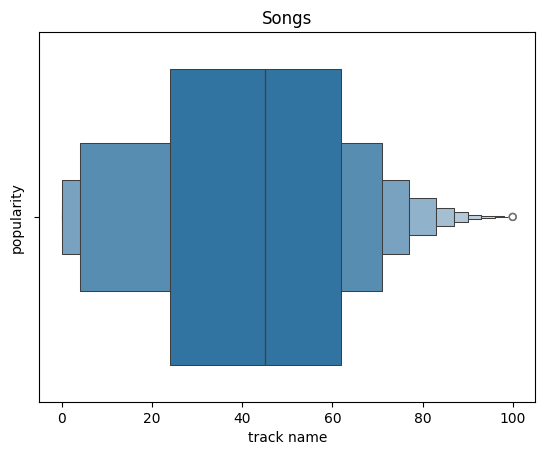

In [4]:
sns.boxenplot(x="track_popularity", data=df)
plt.xlabel("track name")
plt.ylabel("popularity")
plt.title("Songs")

In [5]:
df["track_popularity"].describe().apply(format)

count               32833.0
mean     42.477080985593766
std      24.984074486186937
min                     0.0
25%                    24.0
50%                    45.0
75%                    62.0
max                   100.0
Name: track_popularity, dtype: object

<Axes: >

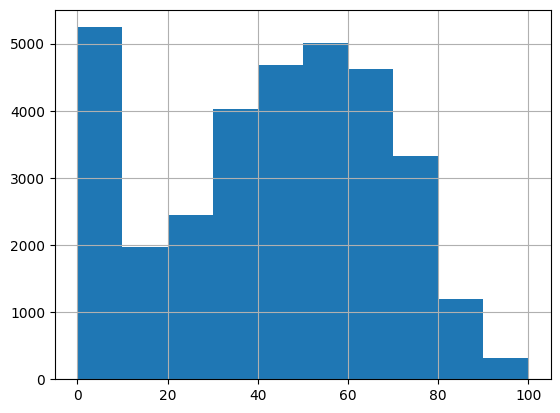

In [6]:
df["track_popularity"].hist()

In [7]:
df["Populariy_bool"]= df["track_popularity"] >= 50

df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,Unnamed: 5,track_album_name,track_album_release_date,playlist_name,playlist_name.1,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Populariy_bool
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,NaN,I Don't Care (with Justin Bieber) [Loud Luxury...,14-06-2019,Pop Remix,Pop Remix,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,True
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,NaN,Memories (Dillon Francis Remix),13-12-2019,Pop Remix,Pop Remix,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,True
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,NaN,All the Time (Don Diablo Remix),2019-05-07 00:00:00,Pop Remix,Pop Remix,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,True
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,NaN,Call You Mine - The Remixes,19-07-2019,Pop Remix,Pop Remix,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,True
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,NaN,Someone You Loved (Future Humans Remix),2019-05-03 00:00:00,Pop Remix,Pop Remix,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,True


<Axes: title={'center': 'class banlance'}, xlabel='Popularity', ylabel='Frequency'>

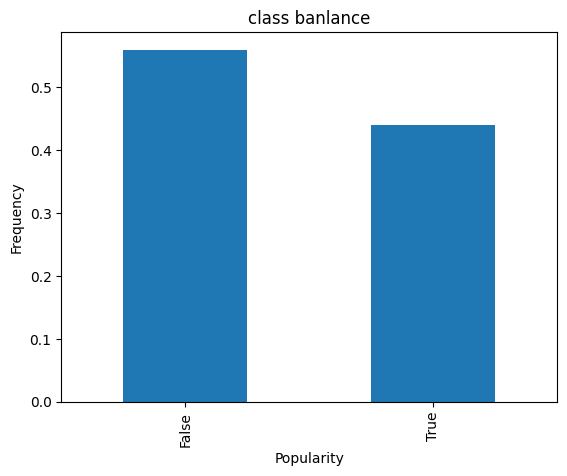

In [8]:
df["Populariy_bool"].value_counts(normalize = True).plot(
    kind = "bar",
    xlabel= "Popularity",
    ylabel= "Frequency",
    title= "class banlance"
)

Text(0.5, 1.0, 'Distribution of popularity')

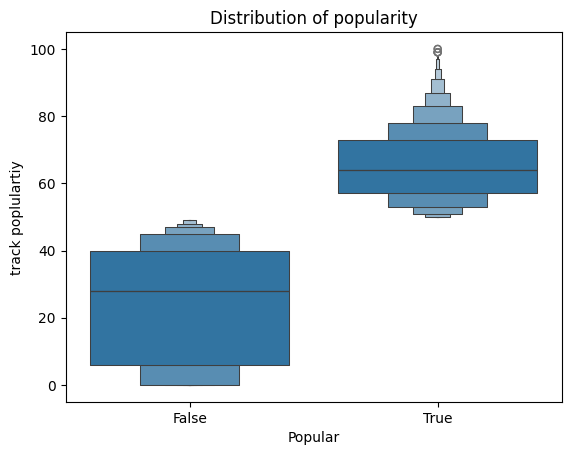

In [9]:
sns.boxenplot(x="Populariy_bool", y= "track_popularity", data= df )



plt.xlabel("Popular")
plt.ylabel("track poplulartiy")
plt.title("Distribution of popularity")

In [10]:
df["track_popularity"].describe().round(2)

count    32833.00
mean        42.48
std         24.98
min          0.00
25%         24.00
50%         45.00
75%         62.00
max        100.00
Name: track_popularity, dtype: float64

           a1        a2        a3        a4        a5        a6        a7  \
a1   1.000000  0.064748 -0.109112 -0.000650  0.057687  0.010637  0.006819   
a2   0.064748  1.000000 -0.086073  0.011736  0.025335 -0.058647  0.181721   
a3  -0.109112 -0.086073  1.000000  0.010052  0.676625 -0.004800 -0.032150   
a4  -0.000650  0.011736  0.010052  1.000000  0.000959 -0.174093  0.022607   
a5   0.057687  0.025335  0.676625  0.000959  1.000000 -0.019289  0.010339   
a6   0.010637 -0.058647 -0.004800 -0.174093 -0.019289  1.000000 -0.063512   
a7   0.006819  0.181721 -0.032150  0.022607  0.010339 -0.063512  1.000000   
a8   0.085159 -0.024519 -0.539745  0.004306 -0.361638  0.009415  0.026092   
a9  -0.149872 -0.008655  0.033247  0.005968 -0.147824 -0.006741 -0.103424   
a10 -0.054584 -0.123859  0.161223  0.002887  0.077613 -0.005549  0.055426   
a11  0.033231  0.330523  0.151103  0.019914  0.053384  0.002614  0.064659   
a12 -0.005378 -0.184084  0.149951 -0.013370  0.093767  0.014329  0.044603   

<Axes: >

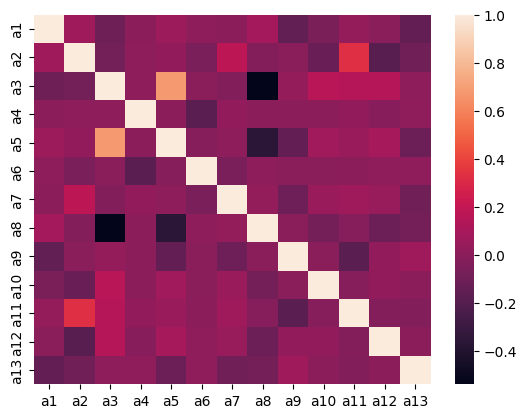

In [11]:
data = {
    "a1" : df["track_popularity"],
    "a2" : df["danceability"],
    "a3" : df["energy"],
    "a4" : df["key"],
    "a5" : df["loudness"],
    "a6" : df["mode"],
    "a7" : df["speechiness"],
    "a8" : df["acousticness"],
    "a9" : df["instrumentalness"],
    "a10" : df["liveness"],
    "a11" : df["valence"],
    "a12" : df["tempo"],
    "a13" : df["duration_ms"],
}

first  = pd.DataFrame(data)
print(first.corr())
corelation = first.corr()
sns.heatmap(corelation)

In [12]:
df["Populariy_bool"].value_counts()

Populariy_bool
False    18373
True     14460
Name: count, dtype: int64

In [13]:
pd.set_option('display.max_columns', None)

In [14]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,Unnamed: 5,track_album_name,track_album_release_date,playlist_name,playlist_name.1,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Populariy_bool
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,NaN,I Don't Care (with Justin Bieber) [Loud Luxury...,14-06-2019,Pop Remix,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,True
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,NaN,Memories (Dillon Francis Remix),13-12-2019,Pop Remix,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,True
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,NaN,All the Time (Don Diablo Remix),2019-05-07 00:00:00,Pop Remix,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,True
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,NaN,Call You Mine - The Remixes,19-07-2019,Pop Remix,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,True
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,NaN,Someone You Loved (Future Humans Remix),2019-05-03 00:00:00,Pop Remix,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,True


In [15]:
cols_unique = df[["playlist_name", "playlist_name.1", "playlist_genre", "playlist_subgenre", ] ]
for i in cols_unique:
    unique_values = df[i].unique()
    print(f"unique Values in {i} are as follows:  {unique_values}")

unique Values in playlist_name are as follows:  ['Pop Remix' 'Dance Pop' 'Dance Room' 'Cardio' 'Dance Pop Hits'
 'Pop Warmup 130 BPM' 'Dance Pop: Japan' 'K-Party Dance Mix'
 'Dance Pop Tunes' 'Pop / Dance' 'Todo Ã‰xitos' '90s Dance Hits'
 'Christian Dance Party' 'Pop Dance Hits' 'Best of 2019 Dance Pop: Japan'
 'Ultimate Indie Presents... Best Indie Tracks of the 2010s'
 'TUNES DANCE AND POP'
 'Pop InglÃ©s (2020 - 2010s)ðŸ’™ MÃºsica En InglÃ©s 2010s'
 'ELETRIC POP & DANCE' 'Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop'
 'The Sound of Post-Teen Pop' 'Post teen pop'
 'post-teen alternative, indie, pop (large variety)'
 'Pop Punk | Post-Hardcore' 'Post pop teen' 'Intro to Post-Teen Pop'
 'ðŸ¤©ðŸ¤ªPost Teen PopðŸ¤ªðŸ¤©'
 'Someone You Loved Lewis Capaldi (Pop Music Mix)'
 "Dr. Q's Prescription PlaylistðŸ’Š" 'a taste of the mainstream'
 'post teen pop' 'BALLARE - Ø±Ù‚Øµ' 'Post Teen Pop' 'Post-Teen Pop'
 'Post-teen pop' 'post-teen pop' 'Electro Pop | Electropop'
 'Electropop Hits 2017-2020

In [16]:
true_count = 0
false_count = 0
for i, f in zip ( df["playlist_name"], df["playlist_name.1"]):
    if i == f:
        print(True)
        true_count+=1
    

    else:
        print(False)
        false_count+=1
print(f"True counts are: {true_count}, and False counts are: {false_count}")

    

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [17]:
df.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   track_id                  32833 non-null  object
 1   track_name                32827 non-null  object
 2   track_artist              32828 non-null  object
 3   track_album_id            32833 non-null  object
 4   track_album_name          32827 non-null  object
 5   track_album_release_date  32833 non-null  object
 6   playlist_name             32833 non-null  object
 7   playlist_name.1           32833 non-null  object
 8   playlist_id               32833 non-null  object
 9   playlist_genre            32833 non-null  object
 10  playlist_subgenre         32833 non-null  object
dtypes: object(11)
memory usage: 2.8+ MB


In [18]:
df.drop(columns=[ "track_id", "track_album_id","track_album_name", "playlist_name.1", "playlist_id", "Unnamed: 5" ], inplace=True )


In [19]:
df.set_index("track_name", inplace=True)
df.head()

,track_artist,track_popularity,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Populariy_bool
track_name,,,,,,,,,,,,,,,,,,,
I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,14-06-2019,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,True
Memories - Dillon Francis Remix,Maroon 5,67,13-12-2019,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,True
All the Time - Don Diablo Remix,Zara Larsson,70,2019-05-07 00:00:00,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,True
Call You Mine - Keanu Silva Remix,The Chainsmokers,60,19-07-2019,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,True
Someone You Loved - Future Humans Remix,Lewis Capaldi,69,2019-05-03 00:00:00,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,True


In [20]:
df.drop(columns= ["mode"], inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32833 entries, I Don't Care (with Justin Bieber) - Loud Luxury Remix to Typhoon - Original Mix
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_artist              32828 non-null  object 
 1   track_popularity          32833 non-null  int64  
 2   track_album_release_date  32833 non-null  object 
 3   playlist_name             32833 non-null  object 
 4   playlist_genre            32833 non-null  object 
 5   playlist_subgenre         32833 non-null  object 
 6   danceability              32833 non-null  float64
 7   energy                    32833 non-null  float64
 8   key                       32833 non-null  int64  
 9   loudness                  32833 non-null  float64
 10  speechiness               32833 non-null  float64
 11  acousticness              32833 non-null  float64
 12  instrumentalness          32833 non-null  float64
 1

In [22]:
df["duration_ms"].unique()

array([194754, 162600, 176616, ..., 353120, 210112, 367432], dtype=int64)

In [23]:
df = df.astype({
    "track_popularity": float,
    "key": float,
    "duration_ms": float
})

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32833 entries, I Don't Care (with Justin Bieber) - Loud Luxury Remix to Typhoon - Original Mix
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_artist              32828 non-null  object 
 1   track_popularity          32833 non-null  float64
 2   track_album_release_date  32833 non-null  object 
 3   playlist_name             32833 non-null  object 
 4   playlist_genre            32833 non-null  object 
 5   playlist_subgenre         32833 non-null  object 
 6   danceability              32833 non-null  float64
 7   energy                    32833 non-null  float64
 8   key                       32833 non-null  float64
 9   loudness                  32833 non-null  float64
 10  speechiness               32833 non-null  float64
 11  acousticness              32833 non-null  float64
 12  instrumentalness          32833 non-null  float64
 1

In [25]:
df.select_dtypes(include='object').info()

<class 'pandas.core.frame.DataFrame'>
Index: 32833 entries, I Don't Care (with Justin Bieber) - Loud Luxury Remix to Typhoon - Original Mix
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   track_artist              32828 non-null  object
 1   track_album_release_date  32833 non-null  object
 2   playlist_name             32833 non-null  object
 3   playlist_genre            32833 non-null  object
 4   playlist_subgenre         32833 non-null  object
dtypes: object(5)
memory usage: 1.5+ MB


In [26]:
df.drop(columns= ["track_artist", "track_album_release_date", "playlist_name",  "playlist_genre", "playlist_subgenre", "track_popularity" ], inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32833 entries, I Don't Care (with Justin Bieber) - Loud Luxury Remix to Typhoon - Original Mix
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      32833 non-null  float64
 1   energy            32833 non-null  float64
 2   key               32833 non-null  float64
 3   loudness          32833 non-null  float64
 4   speechiness       32833 non-null  float64
 5   acousticness      32833 non-null  float64
 6   instrumentalness  32833 non-null  float64
 7   liveness          32833 non-null  float64
 8   valence           32833 non-null  float64
 9   tempo             32833 non-null  float64
 10  duration_ms       32833 non-null  float64
 11  Populariy_bool    32833 non-null  bool   
dtypes: bool(1), float64(11)
memory usage: 3.0+ MB


In [28]:
target = "Populariy_bool"
X = df.drop(columns= target)
y = df[target]

print("X shape is :", X.shape)
print("y shape is :", y.shape)

X shape is : (32833, 11)
y shape is : (32833,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size= 0.2, random_state= 42

)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (26266, 11)
y_train shape: (26266,)
X_test shape: (6567, 11)
y_test shape: (6567,)


In [50]:
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)
print("X_train_over shape:", X_train_over.shape)
X_train_over.head()

X_train_over shape: (29398, 11)


,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.415,0.658,4.0,-12.051,0.0696,0.000045,0.000735,0.1760,0.450,163.015,168406.0
1,0.655,0.884,6.0,-6.515,0.0602,0.010200,0.000000,0.2590,0.772,140.008,219240.0
2,0.847,0.696,5.0,-6.113,0.0642,0.052000,0.004020,0.0795,0.763,140.678,183253.0
3,0.596,0.910,9.0,-5.937,0.0385,0.000629,0.001370,0.1780,0.484,127.963,182461.0
4,0.877,0.665,1.0,-6.116,0.0538,0.406000,0.000035,0.2320,0.143,122.004,199078.0


In [51]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.5596


In [52]:
clf = make_pipeline( SimpleImputer(), RandomForestClassifier(random_state= 42))
print(clf)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])


In [53]:
cv_acc_score = cross_val_score(clf, X_train_over, y_train_over, cv= 5, n_jobs=-1)
print(cv_acc_score)

[0.72108844 0.71683673 0.7207483  0.72104099 0.84844361]


In [54]:
params = {
    "simpleimputer__strategy":["mean", "median"] ,
    "randomforestclassifier__n_estimators": range(25, 100, 25) ,
    "randomforestclassifier__max_depth": range(10, 50, 10)
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'randomforestclassifier__n_estimators': range(25, 100, 25),
 'randomforestclassifier__max_depth': range(10, 50, 10)}

In [55]:
model = GridSearchCV(
    clf,
    param_grid= params,
    cv = 5,
    n_jobs=-1,
    verbose=1

)
model

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': range(10, 50, 10),
                         'randomforestclassifier__n_estimators': range(25, 100, 25),
                         'simpleimputer__strategy': ['mean', 'median']},
             verbose=1)

In [56]:
model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': range(10, 50, 10),
                         'randomforestclassifier__n_estimators': range(25, 100, 25),
                         'simpleimputer__strategy': ['mean', 'median']},
             verbose=1)

In [57]:
cv_results = pd.DataFrame(model.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.728997,0.101685,0.038065,0.021825,10,25,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.653571,0.654422,0.653571,0.659296,0.710495,0.666271,0.022214,23
1,2.274780,0.215083,0.020816,0.001991,10,25,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.653571,0.654422,0.653571,0.659296,0.710495,0.666271,0.022214,23
2,3.628834,0.237192,0.032228,0.001324,10,50,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.650850,0.662925,0.656293,0.658615,0.717129,0.669162,0.024298,21
3,3.269513,0.148986,0.035772,0.004735,10,50,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.650850,0.662925,0.656293,0.658615,0.717129,0.669162,0.024298,21
4,4.446450,0.324272,0.050313,0.008728,10,75,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.651190,0.665646,0.657993,0.665419,0.721721,0.672394,0.025236,19
5,4.364165,0.161518,0.043958,0.001916,10,75,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.651190,0.665646,0.657993,0.665419,0.721721,0.672394,0.025236,19
6,2.342108,0.207257,0.036461,0.006589,20,25,mean,"{'randomforestclassifier__max_depth': 20, 'ran...",0.706293,0.709524,0.706463,0.708794,0.824290,0.731073,0.046626,17
7,2.287610,0.156997,0.035063,0.002206,20,25,median,"{'randomforestclassifier__max_depth': 20, 'ran...",0.706293,0.709524,0.706463,0.708794,0.824290,0.731073,0.046626,17
8,4.483436,0.100430,0.061820,0.001505,20,50,mean,"{'randomforestclassifier__max_depth': 20, 'ran...",0.714456,0.710204,0.711395,0.720191,0.828712,0.736991,0.045990,11
9,4.386344,0.064221,0.064321,0.002101,20,50,median,"{'randomforestclassifier__max_depth': 20, 'ran...",0.714456,0.710204,0.711395,0.720191,0.828712,0.736991,0.045990,11


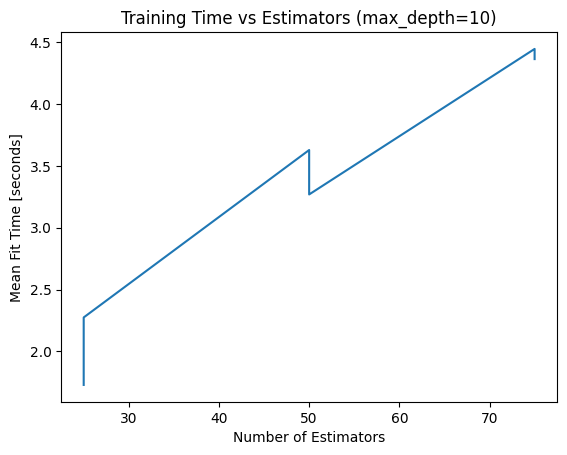

In [58]:
# Create mask
mask = cv_results["param_randomforestclassifier__max_depth"] == 10
# Plot fit time vs n_estimators
plt.plot(
    cv_results[mask]["param_randomforestclassifier__n_estimators"],
    cv_results[mask]["mean_fit_time"]
    
)
# Label axes
plt.xlabel("Number of Estimators")
plt.ylabel("Mean Fit Time [seconds]")
plt.title("Training Time vs Estimators (max_depth=10)");

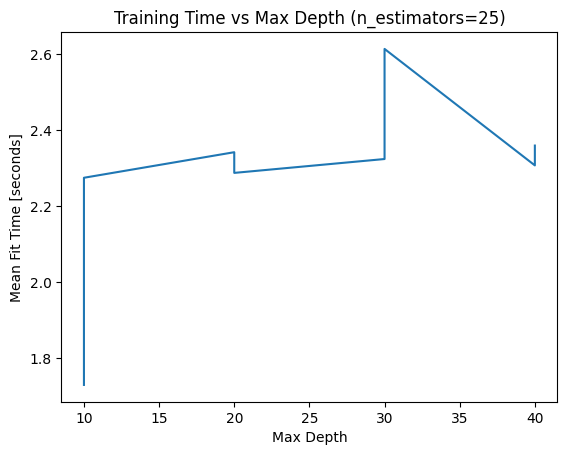

In [59]:
# Create mask

mask = cv_results["param_randomforestclassifier__n_estimators"] == 25
# Plot fit time vs max_depth
plt.plot(
    cv_results[mask]["param_randomforestclassifier__max_depth"],
    cv_results[mask]["mean_fit_time"]
    
)

# Label axes
plt.xlabel("Max Depth")
plt.ylabel("Mean Fit Time [seconds]")
plt.title("Training Time vs Max Depth (n_estimators=25)");

In [60]:
# Extract best hyperparameters
model.best_params_
model.best_score_
model.predict(X_train_over)

array([ True, False, False, ...,  True,  True,  True])

In [61]:
acc_train = model.score(X_train_over, y_train_over)
acc_test = model.score(X_test, y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Test Accuracy:", round(acc_test, 4))

Training Accuracy: 0.9902
Test Accuracy: 0.6973


In [62]:
y_test.value_counts()

Populariy_bool
False    3674
True     2893
Name: count, dtype: int64

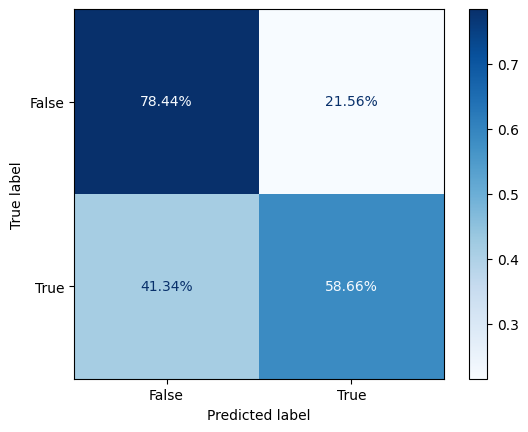

In [65]:
ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    cmap="Blues",
    normalize= "true",
    values_format= ".2%"
    
    )

In [34]:
X_train.head()

,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
track_name,,,,,,,,,,,
Paranoid - 2016 Remaster,0.415,0.658,4.0,-12.051,0.0696,0.000045,0.000735,0.1760,0.450,163.015,168406.0
Generation Of Love,0.655,0.884,6.0,-6.515,0.0602,0.010200,0.000000,0.2590,0.772,140.008,219240.0
Know You Now,0.847,0.696,5.0,-6.113,0.0642,0.052000,0.004020,0.0795,0.763,140.678,183253.0
In Front Of Your Eyes (Radio Edit),0.596,0.910,9.0,-5.937,0.0385,0.000629,0.001370,0.1780,0.484,127.963,182461.0
Plaqtudum - Frijo & Negro Dub Remix,0.877,0.665,1.0,-6.116,0.0538,0.406000,0.000035,0.2320,0.143,122.004,199078.0


In [66]:
pwd

'c:\\mine\\competition'

In [35]:
y_train.head()

track_name
Paranoid - 2016 Remaster                True
Generation Of Love                     False
Know You Now                           False
In Front Of Your Eyes (Radio Edit)     False
Plaqtudum - Frijo & Negro Dub Remix    False
Name: Populariy_bool, dtype: bool

In [36]:
# Fit on `X_train`, `y_train`

model_reg =make_pipeline(
    DecisionTreeClassifier(random_state=42)
)
model_reg.fit(X_train , y_train)  




Pipeline(steps=[('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [37]:
acc_train = model_reg.score(X_train, y_train)
acc_test = model_reg.score(X_test, y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Test Accuracy:", round(acc_test, 4))

Training Accuracy: 0.9893
Test Accuracy: 0.6455


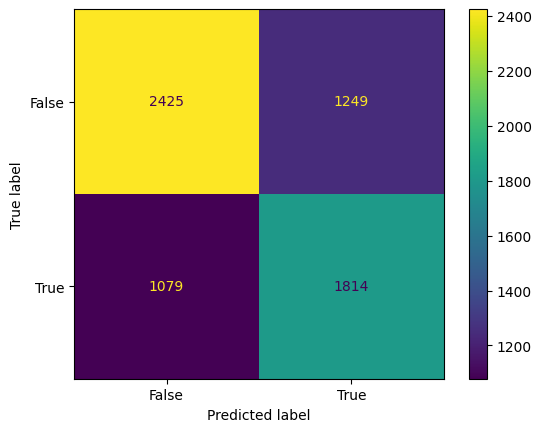

In [38]:
ConfusionMatrixDisplay.from_estimator(model_reg,X_test,y_test)

In [39]:
depth = model_reg.named_steps["decisiontreeclassifier"].get_depth()
print(depth)

35


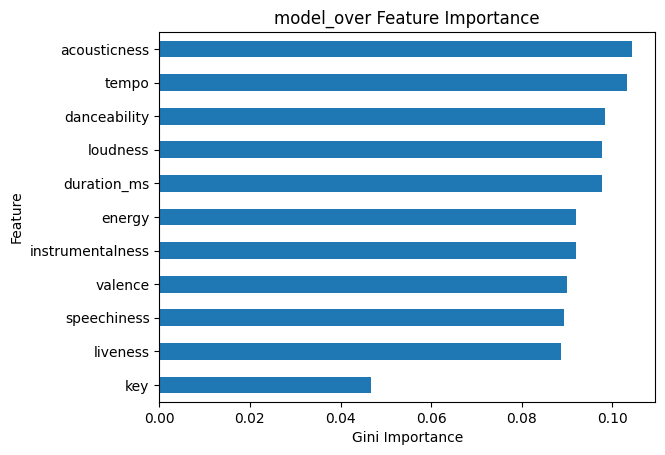

In [40]:
importances = model_reg.named_steps["decisiontreeclassifier"].feature_importances_

# Put importances into a Series
feat_imp = pd.Series(importances, index= X_train.columns).sort_values()
# Plot series
feat_imp.tail(15).plot(kind= "barh")


plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("model_over Feature Importance");

So basically I have to find out the track populariy and its factors why it is popluar, 
so that streaming suggestions can be improved and creators and can make content accordingly.

In [67]:
# data = {
#     "a1" : df["track_popularity"],
#     "a2" : df["danceability"],
#     "a3" : df["energy"],
#     "a4" : df["key"],
#     "a5" : df["loudness"],
#     "a6" : df["mode"],
#     "a7" : df["speechiness"],
#     "a8" : df["acousticness"],
#     "a9" : df["instrumentalness"],
#     "a10" : df["liveness"],
#     "a11" : df["valence"],
#     "a12" : df["tempo"],
#     "a13" : df["duration_ms"],
# }

# first  = pd.DataFrame(data)
# print(first.corr())
# corelation = first.corr()
# sns.heatmap(corelation)



In [68]:
# corelation.describe()